<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Stacked Charts**


Estimated time needed: **45** minutes


In this lab, you will focus on visualizing data specifically using stacked charts. You will use SQL queries to extract the necessary data and apply stacked charts to analyze the composition and comparison within the data.


## Objectives


In this lab, you will perform the following:


- Visualize the composition of data using stacked charts.

- Compare multiple variables across different categories using stacked charts.

- Analyze trends within stacked chart visualizations.


## Setup: Downloading and Loading the Data
**Install the libraries**


In [1]:
!pip install pandas

In [2]:
!pip install matplotlib


**Download and Load the Data**


To start, download and load the dataset into a `pandas` DataFrame.



### Step 1: Download the dataset


In [3]:
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  4.98MB/s    in 31s     

2026-08-30 19:24:41 (4.84 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]


### Step 2: Import necessary libraries and load the dataset


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### Load the data


In [8]:
df = pd.read_csv("survey-data.csv")

### Display the first few rows of the data to understand its structure


In [7]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Stacked Chart for Composition of Job Satisfaction Across Age Groups


##### 1. Stacked Chart of Median `JobSatPoints_6` and `JobSatPoints_7` for Different Age Groups


Visualize the composition of job satisfaction scores (`JobSatPoints_6` and `JobSatPoints_7`) across various age groups. This will help in understanding the breakdown of satisfaction levels across different demographics.



In [12]:
# Let's update the Age Groups as we've done in previous assessments
age_mapping = {
    "Under 18 years old": "<18",
    "18-24 years old": "18-24",
    "25-34 years old": "25-34",
    "35-44 years old": "35-44",
    "45-54 years old": "45-54",
    "55-64 years old": "55-64",
    "65 years or older": "65+"
}

df["Age"] = df["Age"].replace(age_mapping)

In [13]:
# Now Let's check the value_counts
df["Age"].value_counts()

Age
25-34                23911
35-44                14942
18-24                14098
45-54                 6249
55-64                 2575
<18                   2568
65+                    772
Prefer not to say      322
Name: count, dtype: int64

In [14]:
# Let's get the unique Age groups and order by categorical column
age_groups = df["Age"].unique()

df["Age"] = pd.Categorical(
    df["Age"],
    categories=age_groups,
    ordered=True
)

In [15]:
# Calculate the median satisfaction scores
satisfaction_by_age = (
    df.groupby("Age", observed=False)[
        ["JobSatPoints_6", "JobSatPoints_7"]
    ]
    .median()
    .reset_index()
)

satisfaction_by_age

,Age,JobSatPoints_6,JobSatPoints_7
0,<18,1.5,5.0
1,35-44,20.0,15.0
2,45-54,20.0,15.0
3,18-24,15.0,20.0
4,25-34,20.0,15.0
5,55-64,20.0,20.0
6,Prefer not to say,10.0,7.0
7,65+,20.0,15.0


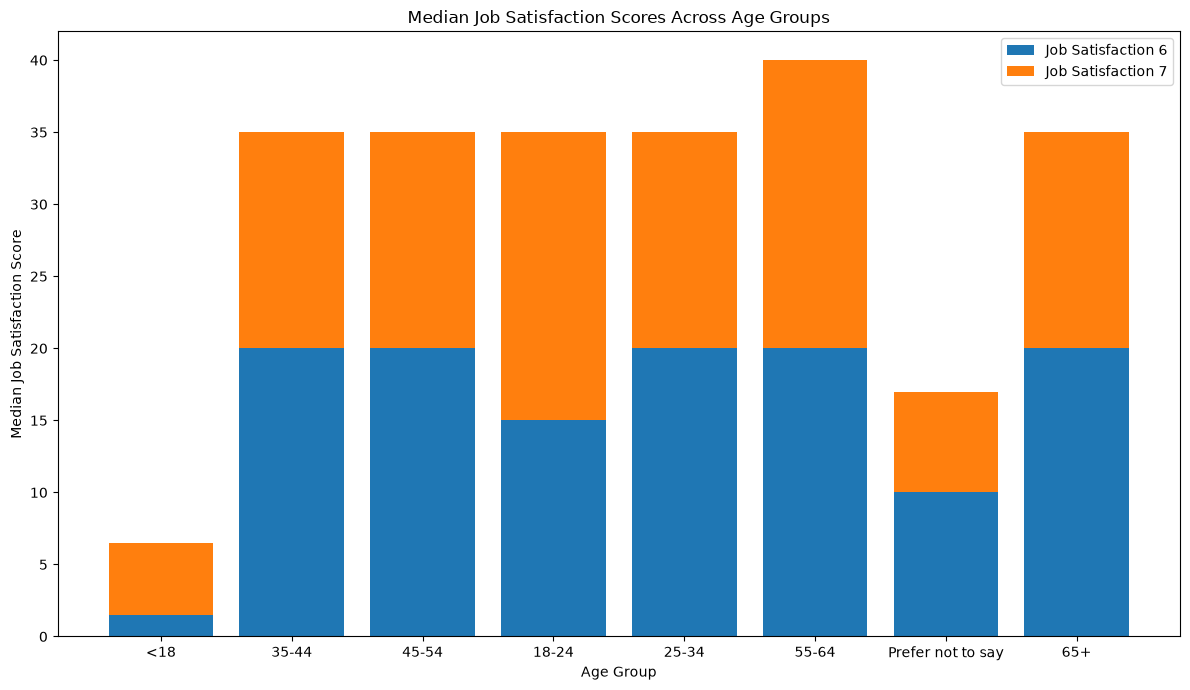

In [16]:
# Visualize our Stacked Chart
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

plt.bar(
    satisfaction_by_age["Age"],
    satisfaction_by_age["JobSatPoints_6"],
    label="Job Satisfaction 6"
)

plt.bar(
    satisfaction_by_age["Age"],
    satisfaction_by_age["JobSatPoints_7"],
    bottom=satisfaction_by_age["JobSatPoints_6"],
    label="Job Satisfaction 7"
)

plt.title(
    "Median Job Satisfaction Scores Across Age Groups"
)

plt.xlabel("Age Group")
plt.ylabel("Median Job Satisfaction Score")

plt.legend()

plt.tight_layout()

plt.show()

##### Stacked Chart of `JobSatPoints_6` and `JobSatPoints_7` for Employment Status


Create a stacked chart to compare job satisfaction (`JobSatPoints_6` and `JobSatPoints_7`) across different employment statuses. This will show how satisfaction varies by employment type.


In [17]:
# Prepare employment data
employment_df = df[
    ["Employment", "JobSatPoints_6", "JobSatPoints_7"]
].copy()

employment_df["JobSatPoints_6"] = pd.to_numeric(
    employment_df["JobSatPoints_6"],
    errors="coerce"
)

employment_df["JobSatPoints_7"] = pd.to_numeric(
    employment_df["JobSatPoints_7"],
    errors="coerce"
)

employment_df = employment_df.dropna(
    subset=["Employment"]
)

In [18]:
# Split the employment categories
employment_df["EmploymentType"] = (
    employment_df["Employment"]
    .str.split(";")
)

employment_df = employment_df.explode(
    "EmploymentType"
)

employment_df["EmploymentType"] = (
    employment_df["EmploymentType"]
    .str.strip()
)

In [20]:
# Calculate the median satisfaction
satisfaction_by_employment = (
    employment_df
    .groupby("EmploymentType")[
        ["JobSatPoints_6", "JobSatPoints_7"]
    ]
    .median()
    .reset_index()
)

satisfaction_by_employment

,EmploymentType,JobSatPoints_6,JobSatPoints_7
0,"Employed, full-time",20.0,15.0
1,"Employed, part-time",15.0,15.0
2,I prefer not to say,NaN,NaN
3,"Independent contractor, freelancer, or self-em...",15.0,15.0
4,"Not employed, and not looking for work",10.0,10.0
5,"Not employed, but looking for work",10.0,10.0
6,Retired,10.0,11.0
7,"Student, full-time",10.0,15.0
8,"Student, part-time",15.0,20.0


In [21]:
# Let's keep the top 8 employment categories
top_employment = (
    employment_df["EmploymentType"]
    .value_counts()
    .head(8)
    .index
)

satisfaction_by_employment = (
    satisfaction_by_employment[
        satisfaction_by_employment["EmploymentType"]
        .isin(top_employment)
    ]
)

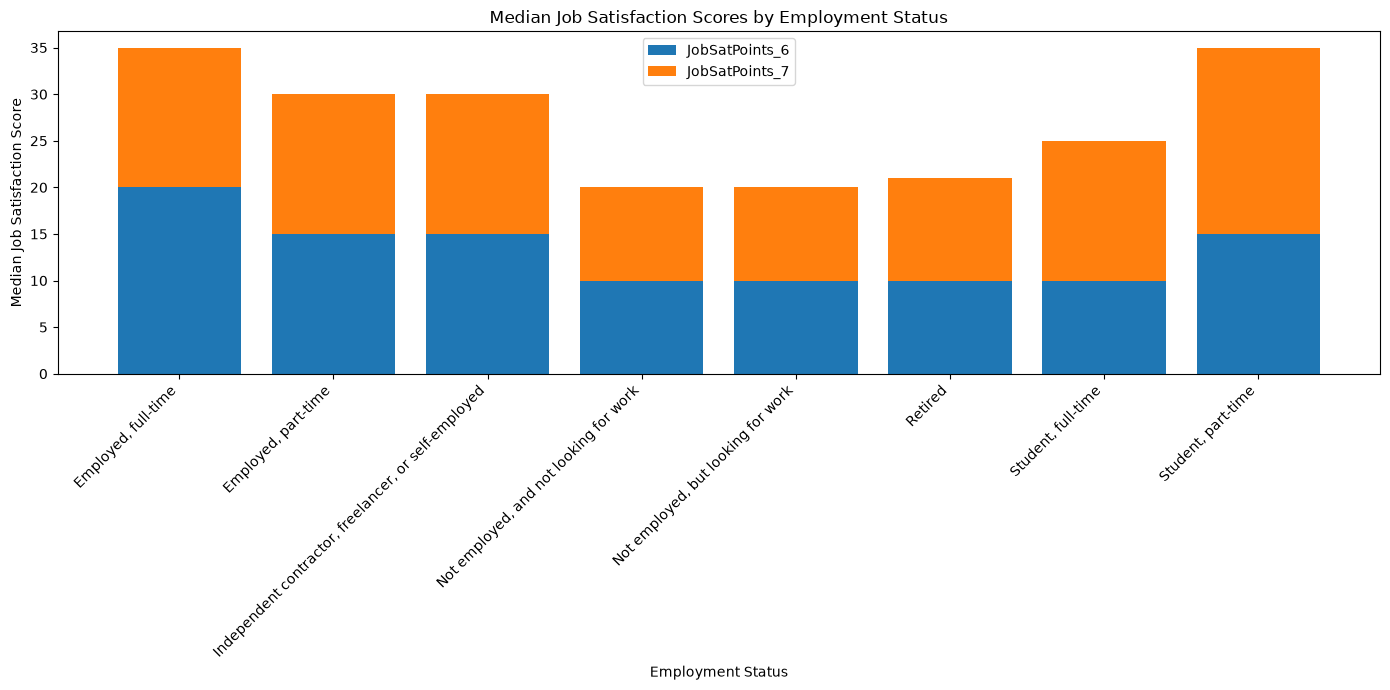

In [22]:
# Visualize the Stacked chart
plt.figure(figsize=(14, 7))

plt.bar(
    satisfaction_by_employment["EmploymentType"],
    satisfaction_by_employment["JobSatPoints_6"],
    label="JobSatPoints_6"
)

plt.bar(
    satisfaction_by_employment["EmploymentType"],
    satisfaction_by_employment["JobSatPoints_7"],
    bottom=satisfaction_by_employment["JobSatPoints_6"],
    label="JobSatPoints_7"
)

plt.title(
    "Median Job Satisfaction Scores by Employment Status"
)

plt.xlabel("Employment Status")
plt.ylabel("Median Job Satisfaction Score")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.legend()

plt.tight_layout()

plt.show()

### Task 2: Stacked Chart for Compensation and Job Satisfaction by Age Group


##### This stacked chart visualizes the composition of compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) specifically for respondents aged 30-35.


In [45]:
# As the dataset doesn't have 30-35 Age categories let's work on with the closest category 25-34
age_25_34 = df[
    df["Age"].eq("25-34")
].copy()

age_25_34

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
14,15,I am a developer by profession,25-34,"Employed, full-time","Hybrid (some remote, some in-person)",Apples,Hobby;Professional development or self-paced l...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Other online resources ...,Stack Overflow;Coding sessions (live or record...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
18,19,I am a developer by profession,25-34,"Employed, full-time","Hybrid (some remote, some in-person)",Apples,Hobby;Professional development or self-paced l...,Some college/university study without earning ...,Books / Physical media;On the job training;Oth...,Technical documentation;Blogs;Books;Stack Over...,...,60.0,10.0,10.0,0.0,0.0,0.0,Appropriate in length,Easy,NaN,10.0
20,21,"I am not primarily a developer, but I write co...",25-34,"Employed, full-time","Hybrid (some remote, some in-person)",Apples,Hobby;Professional development or self-paced l...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Other online resources (e.g., videos, blogs, f...",Written Tutorials;Stack Overflow;Interactive t...,...,100.0,90.0,90.0,100.0,90.0,100.0,Appropriate in length,Easy,NaN,6.0
27,28,I am a developer by profession,25-34,"Employed, full-time;Independent contractor, fr...",Remote,Apples,Hobby,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",Books / Physical media;On the job training,NaN,...,50.0,20.0,15.0,15.0,0.0,0.0,Appropriate in length,Neither easy nor difficult,NaN,7.0
28,29,I am a developer by profession,25-34,"Independent contractor, freelancer, or self-em...",Remote,Apples,Hobby;Other (please specify):;Bootstrapping a ...,"Secondary school (e.g. American high school, G...",On the job training;Other online resources (e....,Technical documentation;Written Tutorials;Stac...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65424,65425,I am a developer by profession,25-34,"Employed, full-time",Remote,Apples,Hobby,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65427,65428,"I am not primarily a developer, but I write co...",25-34,"Not employed, but looking for work;Employed, p...",In-person,Apples,Hobby;Professional development or self-paced l...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65428,65429,I am a developer by profession,25-34,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Profe...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;Other online ...,Technical documentation;Books;Interactive tuto...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65433,65434,I am a developer by profession,25-34,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [47]:
# Calculate the median values
median_compensation = age_25_34[
    "ConvertedCompYearly"
].median()

median_job_sat = age_25_34[
    "JobSatPoints_6"
].median()

print(f"Median Compensation: ${median_compensation:,.0f}")
print(f"Median Job Satisfaction: {median_job_sat:.1f}")

Median Compensation: $59,825
Median Job Satisfaction: 20.0

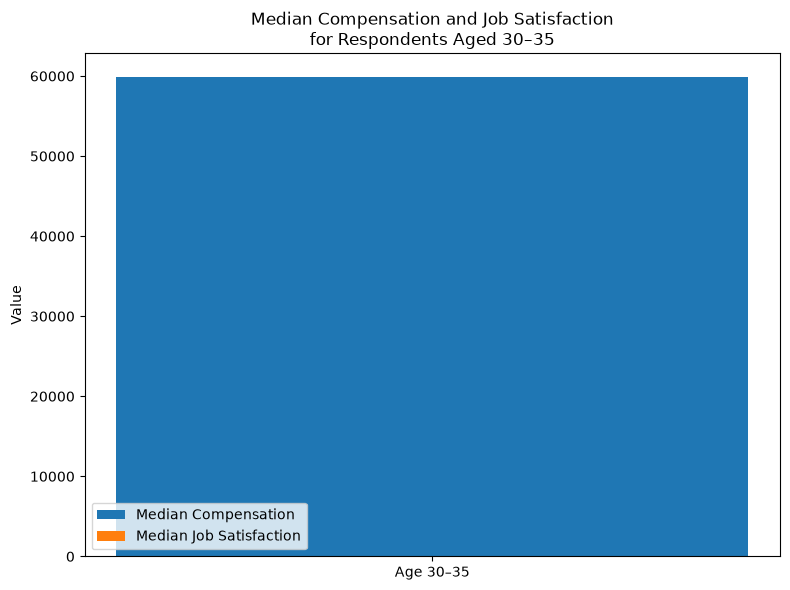

In [48]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(8, 6))

plt.bar(
    ["Age 30–35"],
    [median_compensation],
    label="Median Compensation"
)

plt.bar(
    ["Age 30–35"],
    [median_job_sat],
    bottom=[median_compensation],
    label="Median Job Satisfaction"
)

plt.title(
    "Median Compensation and Job Satisfaction\n"
    "for Respondents Aged 30–35"
)

plt.ylabel("Value")

plt.legend()

plt.tight_layout()

plt.show()

In [51]:
# As the Compensation is highly skewed in relation to job satisfaction
# The job satisfaction segment would be almost imposible to see as you can notice in the previous stacked chart
# Let's use 95th percentile of compensation as the reference point. This is particularly appropriate because compensation can contain extreme outliers.
# Calculate the 95th percentile of compensation
compensation_max = age_25_34[
    "ConvertedCompYearly"
].quantile(0.95)

# Scale compensation to 0–100
compensation_scaled = (
    median_compensation / compensation_max
) * 100

# Job satisfaction is already 0–100
job_sat_scaled = median_job_sat

print(f"Compensation 99th percentile: ${compensation_max:,.0f}")
print(f"Scaled compensation: {compensation_scaled:.1f}")
print(f"Job satisfaction: {job_sat_scaled:.1f}")

Compensation 99th percentile: $187,236
Scaled compensation: 32.0
Job satisfaction: 20.0

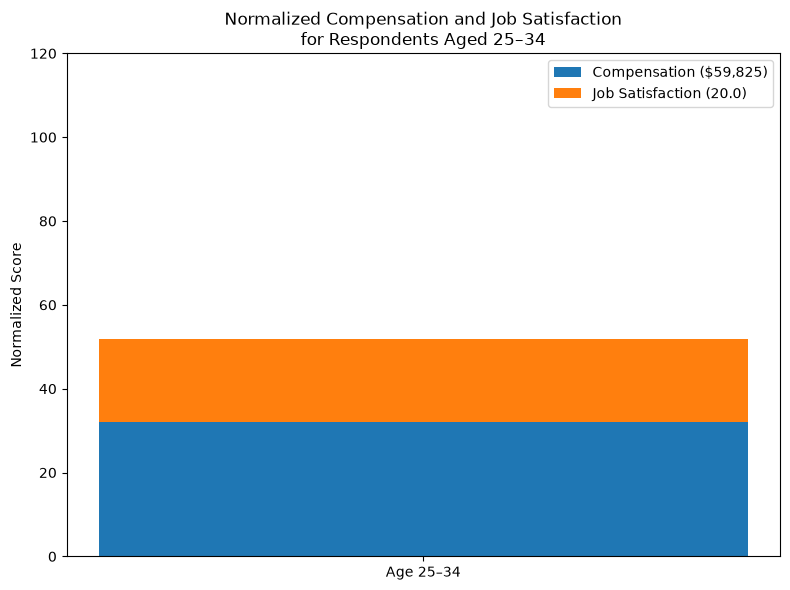

In [52]:
# Now Let's plot the chart
plt.figure(figsize=(8, 6))

plt.bar(
    ["Age 25–34"],
    [compensation_scaled],
    label=f"Compensation (${median_compensation:,.0f})"
)

plt.bar(
    ["Age 25–34"],
    [job_sat_scaled],
    bottom=[compensation_scaled],
    label=f"Job Satisfaction ({median_job_sat:.1f})"
)

plt.title(
    "Normalized Compensation and Job Satisfaction\n"
    "for Respondents Aged 25–34"
)

plt.ylabel("Normalized Score")

plt.ylim(0, 120)

plt.legend()

plt.tight_layout()

plt.show()

**Conclusion:** The visualization compares normalized median compensation and job satisfaction for respondents aged 25–34. Compensation was normalized using the 99th percentile to reduce the influence of extreme salary values, while job satisfaction already uses a 0–100 scale.

##### Stacked Chart of Median Compensation and Job Satisfaction Across Age Group


Compare the median compensation and job satisfaction metrics across different age groups. This helps visualize how compensation and satisfaction levels differ by age.


In [53]:
# Let's calculate the median values by age group
age_satisfaction = (
    df.groupby("Age", observed=False)[
        ["ConvertedCompYearly", "JobSatPoints_6"]
    ]
    .median()
    .reindex(age_groups)
)

age_satisfaction

,ConvertedCompYearly,JobSatPoints_6
Age,,
<18,7626.5,1.5
35-44,84796.0,20.0
45-54,99099.0,20.0
18-24,25000.0,15.0
25-34,59825.0,20.0
55-64,109691.0,20.0
Prefer not to say,140000.0,10.0
65+,106000.0,20.0


In [55]:
# Let's use 95th percentile to normalize compensation
compensation_95 = df[
    "ConvertedCompYearly"
].quantile(0.95)

age_satisfaction["CompensationScaled"] = (
    age_satisfaction["ConvertedCompYearly"]
    / compensation_95
) * 100

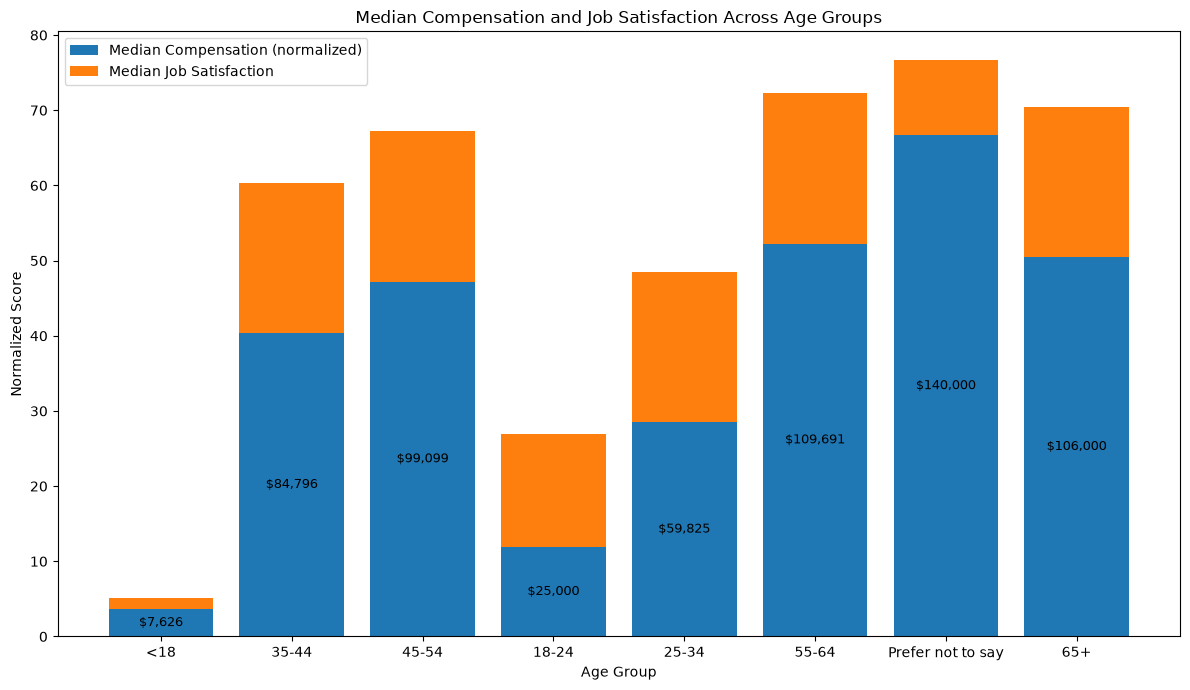

In [56]:
# Plot the Stacked bar chart
plt.figure(figsize=(12, 7))

plt.bar(
    age_satisfaction.index,
    age_satisfaction["CompensationScaled"],
    label="Median Compensation (normalized)"
)

plt.bar(
    age_satisfaction.index,
    age_satisfaction["JobSatPoints_6"],
    bottom=age_satisfaction["CompensationScaled"],
    label="Median Job Satisfaction"
)

for i, row in age_satisfaction.iterrows():
    plt.text(
        i,
        row["CompensationScaled"] / 2,
        f"${row['ConvertedCompYearly']:,.0f}",
        ha="center",
        va="center",
        fontsize=9
    )

plt.title(
    "Median Compensation and Job Satisfaction Across Age Groups"
)

plt.xlabel("Age Group")
plt.ylabel("Normalized Score")

plt.legend()

plt.tight_layout()

plt.show()

### Task 3: Comparing Data Using Stacked Charts


##### 1. Stacked Chart of Preferred Databases by Age Group




Visualize the top databases that respondents from different age groups wish to learn. Create a stacked chart to show the proportion of each database in each age group.


In [64]:
# Preparing the data
database_df = df[
    ["Age", "DatabaseWantToWorkWith"]
].dropna().copy()

database_df["Database"] = (
    database_df["DatabaseWantToWorkWith"]
    .str.split(";")
)

database_df = database_df.explode(
    "Database"
).reset_index(drop=True)

database_df["Database"] = (
    database_df["Database"]
    .str.strip()
)

In [69]:
# Let's identify the top 5 databases
top_databases = (
    database_df["Database"]
    .value_counts()
    .head(5)
    .index
)

top_databases

Index(['PostgreSQL', 'SQLite', 'MySQL', 'MongoDB', 'Redis'], dtype='str', name='Database')

In [70]:
# And filter for those databases
database_df = database_df[
    database_df["Database"].isin(top_databases)
]

In [71]:
# Calculate proportions by age group
database_by_age = pd.crosstab(
    database_df["Age"],
    database_df["Database"],
    normalize="index"
) * 100

In [72]:
# Reorderting by aging group
database_by_age = database_by_age.reindex(
    age_groups
)

database_by_age

Database,MongoDB,MySQL,PostgreSQL,Redis,SQLite
Age,,,,,
<18,18.625498,20.468127,25.199203,10.408367,25.298805
35-44,13.141734,15.573569,35.427413,17.065831,18.791452
45-54,12.354163,17.979863,35.176602,13.824517,20.664855
18-24,18.341008,18.643965,30.980368,13.542172,18.492487
25-34,15.699892,16.066931,34.267722,16.344009,17.621447
55-64,11.153480,22.449952,34.509056,8.388942,23.498570
Prefer not to say,12.745098,20.098039,29.901961,10.294118,26.960784
65+,10.067114,31.991051,24.161074,4.474273,29.306488


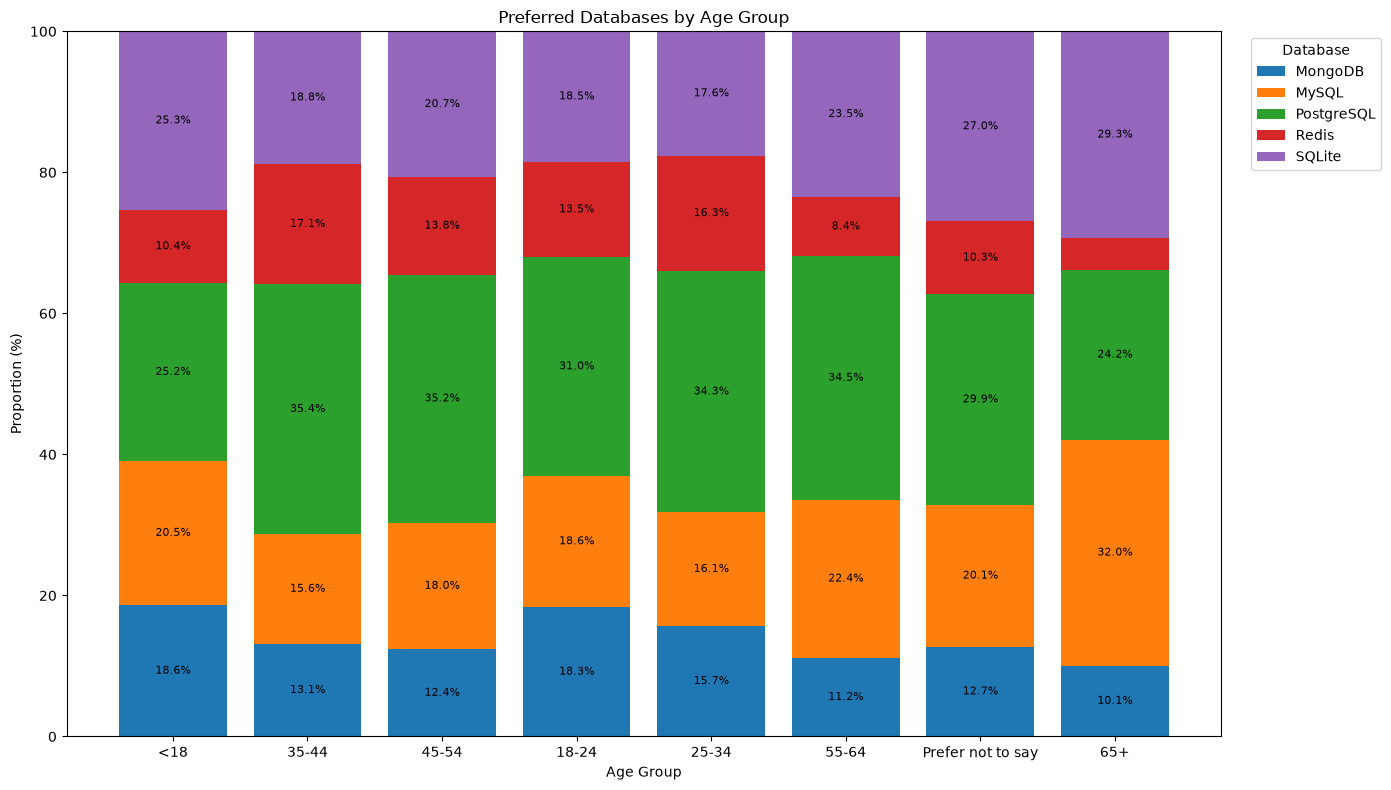

In [73]:
# Visualizing the Stacked chart
plt.figure(figsize=(14, 8))

bottom = np.zeros(len(database_by_age))

for database in database_by_age.columns:

    values = database_by_age[database].values

    plt.bar(
        database_by_age.index,
        values,
        bottom=bottom,
        label=database
    )

    for i, value in enumerate(values):

        if value >= 5:
            plt.text(
                i,
                bottom[i] + value / 2,
                f"{value:.1f}%",
                ha="center",
                va="center",
                fontsize=8
            )

    bottom += values

plt.title(
    "Preferred Databases by Age Group"
)

plt.xlabel("Age Group")
plt.ylabel("Proportion (%)")

plt.ylim(0, 100)

plt.legend(
    title="Database",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

##### 2. Stacked Chart of Employment Type by Job Satisfaction


Analyze the distribution of employment types within each job satisfaction level using a stacked chart. This will provide insights into how employment types are distributed across various satisfaction ratings.


In [74]:
# Prepare the data
employment_df = df[
    ["JobSatPoints_6", "Employment"]
].dropna().copy()

# Convert job satisfaction to numeric
employment_df["JobSatPoints_6"] = pd.to_numeric(
    employment_df["JobSatPoints_6"],
    errors="coerce"
)

# Split multiple employment types
employment_df["EmploymentType"] = (
    employment_df["Employment"]
    .str.split(";")
)

employment_df = employment_df.explode(
    "EmploymentType"
).reset_index(drop=True)

employment_df["EmploymentType"] = (
    employment_df["EmploymentType"]
    .str.strip()
)

In [75]:
# Finding the most common employment types
top_employment = (
    employment_df["EmploymentType"]
    .value_counts()
    .head(5)
)

top_employment

EmploymentType
Employed, full-time                                     26510
Independent contractor, freelancer, or self-employed     4310
Employed, part-time                                      1839
Student, full-time                                       1059
Student, part-time                                        954
Name: count, dtype: int64

In [76]:
# Create the cross-tabulation
employment_top5 = employment_df[
    employment_df["EmploymentType"].isin(
        top_employment.index
    )
]

employment_by_sat = pd.crosstab(
    employment_top5["JobSatPoints_6"],
    employment_top5["EmploymentType"],
    normalize="index"
) * 100

In [80]:
# Let's get the top 10 satisfaction levels
top_satisfaction = (
    employment_df["JobSatPoints_6"]
    .value_counts()
    .head(10)
    .index
    .sort_values()
)

employment_by_sat = employment_by_sat.loc[
    employment_by_sat.index.isin(top_satisfaction)
]

employment_df["SatisfactionGroup"] = pd.cut(
    employment_df["JobSatPoints_6"],
    bins=[-1, 20, 40, 60, 80, 100],
    labels=[
        "0–20",
        "21–40",
        "41–60",
        "61–80",
        "81–100"
    ]
)

employment_by_sat = pd.crosstab(
    employment_df["SatisfactionGroup"],
    employment_df["EmploymentType"],
    normalize="index"
) * 100

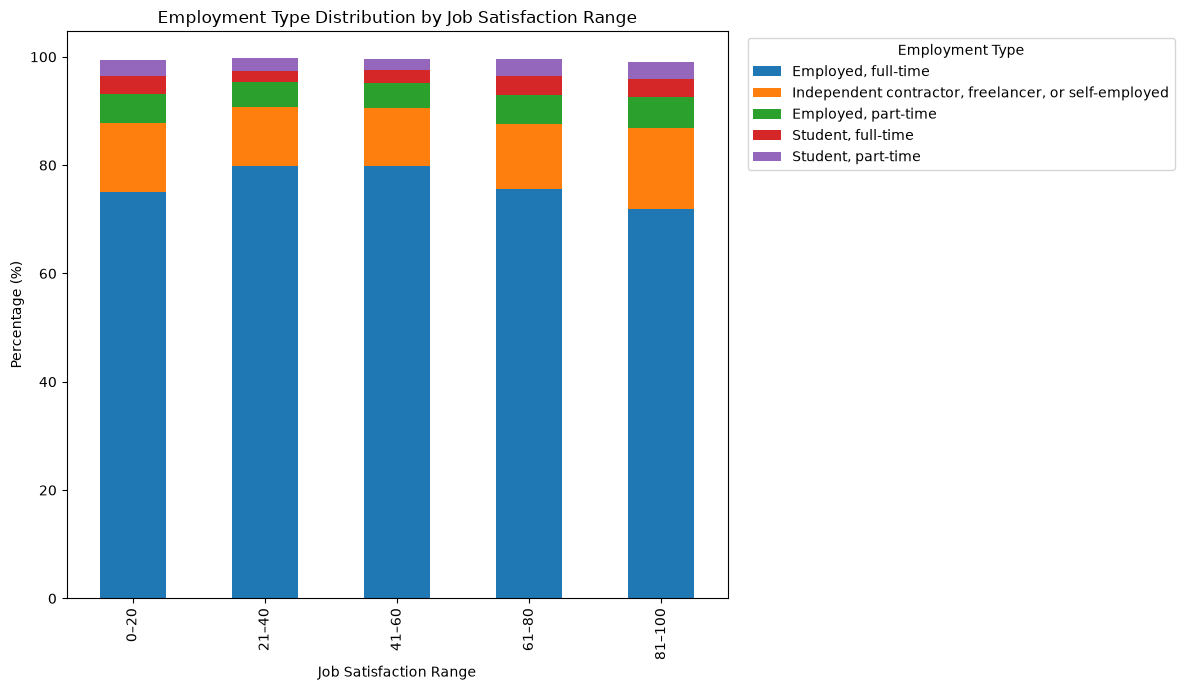

In [81]:
# Visualize StackedBar
employment_by_sat[top_employment.index].plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7)
)

plt.title(
    "Employment Type Distribution by Job Satisfaction Range"
)

plt.xlabel("Job Satisfaction Range")
plt.ylabel("Percentage (%)")

plt.legend(
    title="Employment Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()


### Task 4: Exploring Technology Preferences Using Stacked Charts


##### 1. Stacked Chart for Preferred Programming Languages by Age Group


Analyze how programming language preferences (`LanguageAdmired`) vary across age groups.


In [82]:
# Let's prepare the dataframe
language_df = df[
    ["Age", "LanguageAdmired"]
].dropna().copy()

# Split multiple languages
language_df["Language"] = (
    language_df["LanguageAdmired"]
    .str.split(";")
)

# Create one row per language selection
language_df = language_df.explode(
    "Language"
).reset_index(drop=True)

language_df["Language"] = (
    language_df["Language"]
    .str.strip()
)

In [83]:
# Find the top 5 admired languages
top_languages = (
    language_df["Language"]
    .value_counts()
    .head(5)
)

top_languages

Language
JavaScript    21869
Python        20774
SQL           20692
HTML/CSS      19851
TypeScript    16079
Name: count, dtype: int64

In [84]:
# Filtee to keep only top 5
language_top5 = language_df[
    language_df["Language"].isin(
        top_languages.index
    )
]

In [86]:
# Calculate proportions by age groups
language_by_age = pd.crosstab(
    language_top5["Age"],
    language_top5["Language"],
    normalize="index"
) * 100

language_by_age = language_by_age.reindex(
    age_groups
)

language_by_age

Language,HTML/CSS,JavaScript,Python,SQL,TypeScript
Age,,,,,
<18,25.756439,22.980745,27.631908,11.002751,12.628157
35-44,20.086838,22.634972,18.591290,22.170080,16.516819
45-54,19.605707,22.339614,19.627492,25.944886,12.482300
18-24,20.578734,21.511443,23.463306,18.217389,16.229128
25-34,18.997152,21.732939,20.349984,20.582758,18.337167
55-64,19.735026,22.605575,20.452664,28.374275,8.832459
Prefer not to say,24.808184,21.739130,26.854220,16.112532,10.485934
65+,21.806452,21.935484,25.032258,26.322581,4.903226


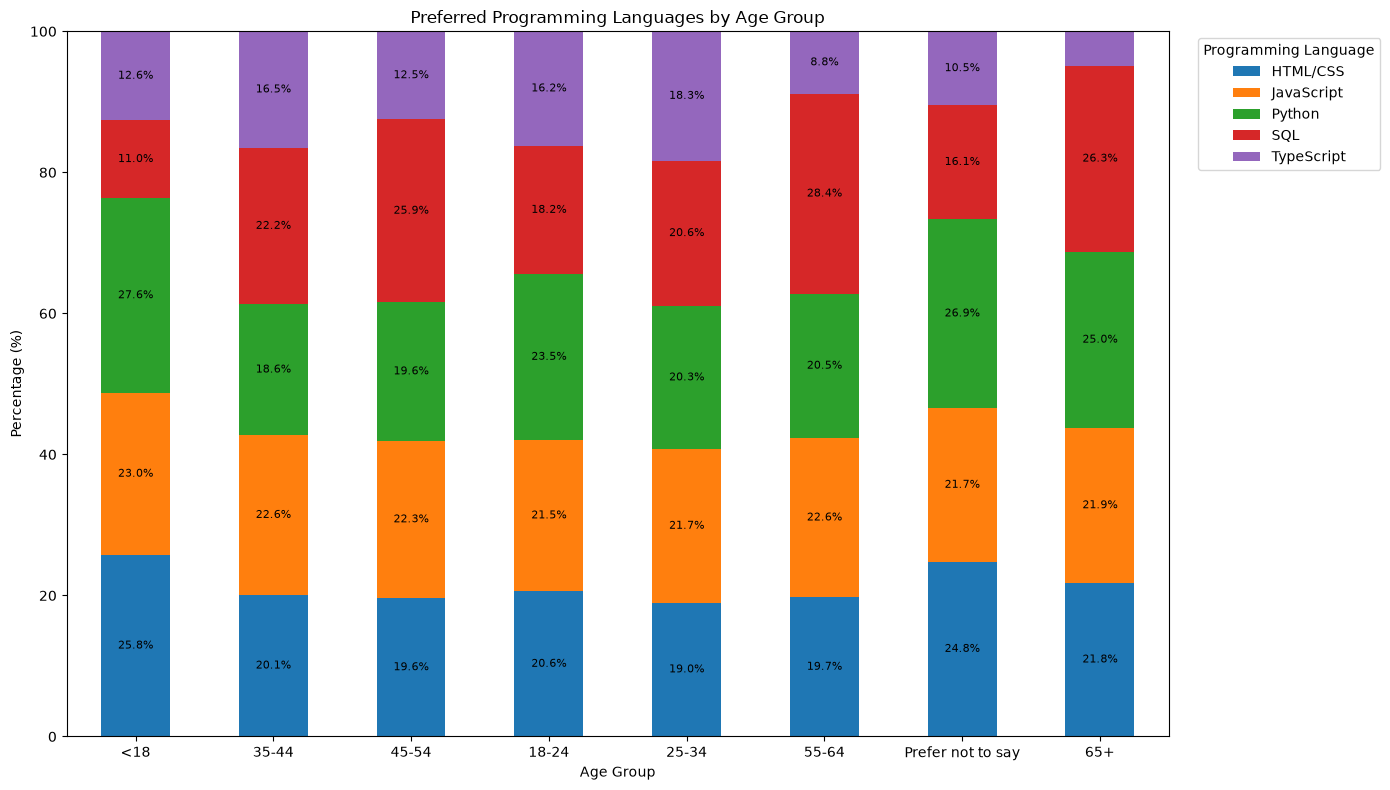

In [87]:
# Stacked bar chart
ax = language_by_age.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 8)
)

for container in ax.containers:
    labels = [
        f"{bar.get_height():.1f}%"
        if bar.get_height() >= 5
        else ""
        for bar in container
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=8
    )

plt.title(
    "Preferred Programming Languages by Age Group"
)

plt.xlabel("Age Group")
plt.ylabel("Percentage (%)")

plt.ylim(0, 100)

plt.xticks(rotation=0)

plt.legend(
    title="Programming Language",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

##### 2. Stacked Chart for Technology Adoption by Employment Type


Explore how admired platforms (`PlatformAdmired`) differ across employment types (e.g., full-time, freelance)


In [89]:
# Preparing the data
platform_df = df[
    ["Employment", "PlatformAdmired"]
].dropna().copy()

# Split multiple employment types
platform_df["EmploymentType"] = (
    platform_df["Employment"]
    .str.split(";")
)

platform_df = platform_df.explode(
    "EmploymentType"
).reset_index(drop=True)

platform_df["EmploymentType"] = (
    platform_df["EmploymentType"]
    .str.strip()
)

# Split multiple admired platforms
platform_df["Platform"] = (
    platform_df["PlatformAdmired"]
    .str.split(";")
)

platform_df = platform_df.explode(
    "Platform"
).reset_index(drop=True)

platform_df["Platform"] = (
    platform_df["Platform"]
    .str.strip()
)

In [90]:
# Finding top 5 platforms
top_platforms = (
    platform_df["Platform"]
    .value_counts()
    .head(5)
)

top_platforms

Platform
Amazon Web Services (AWS)    16729
Microsoft Azure               9110
Google Cloud                  7982
Cloudflare                    6187
Firebase                      4622
Name: count, dtype: int64

In [91]:
# Filter to keep only top 5
platform_top5 = platform_df[
    platform_df["Platform"].isin(
        top_platforms.index
    )
]

In [92]:
# Calculate proportions
platform_by_employment = pd.crosstab(
    platform_top5["EmploymentType"],
    platform_top5["Platform"],
    normalize="index"
) * 100

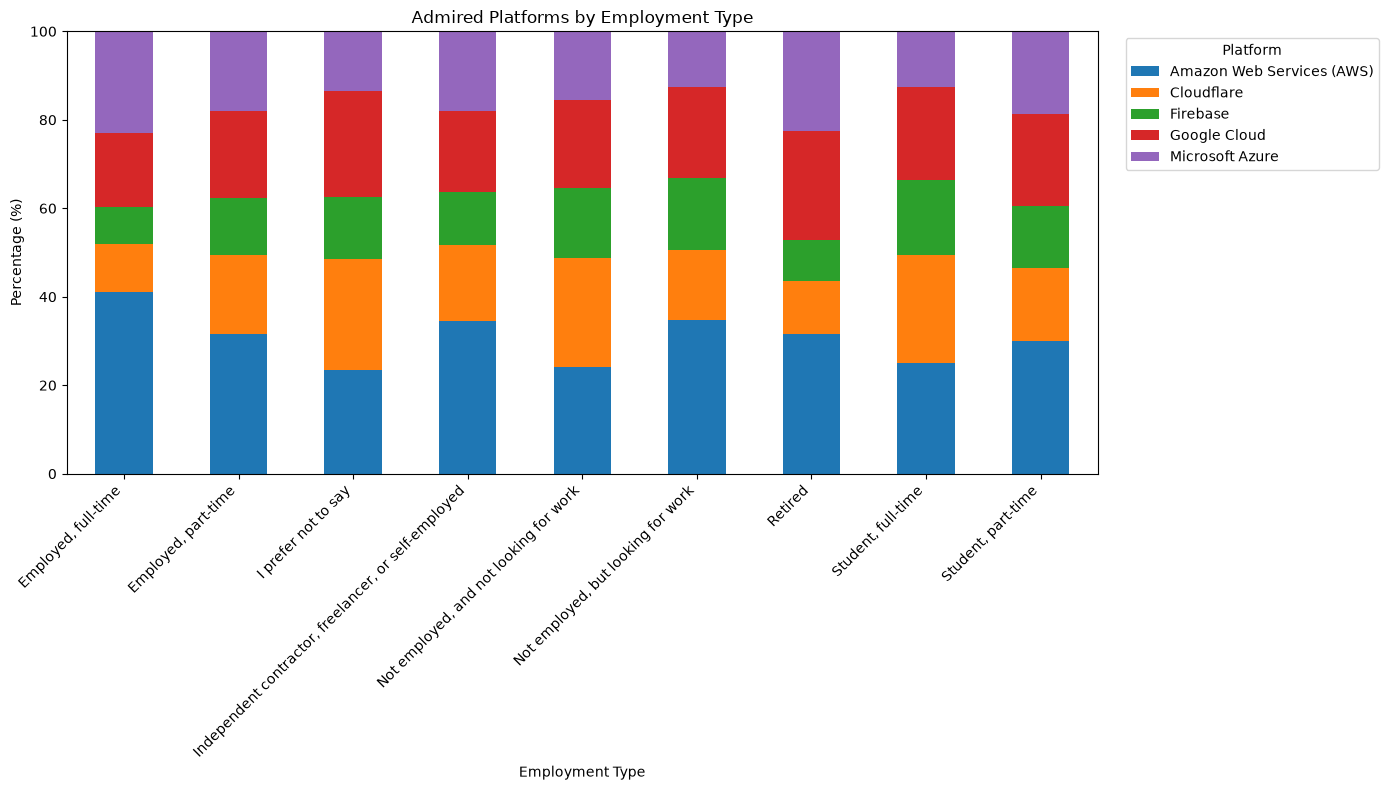

In [93]:
# Visualizing Stacked Chart
ax = platform_by_employment.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 8)
)

plt.title(
    "Admired Platforms by Employment Type"
)

plt.xlabel("Employment Type")
plt.ylabel("Percentage (%)")

plt.ylim(0, 100)

plt.xticks(rotation=45, ha="right")

plt.legend(
    title="Platform",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

### Final Step: Review


In this lab, you focused on using stacked charts to understand the composition and comparison within the dataset. Stacked charts provided insights into job satisfaction, compensation, and preferred databases across age groups and employment types.


## Summary


After completing this lab, you will be able to:

- Use stacked charts to analyze the composition of data across categories, such as job satisfaction and compensation by age group.

- Compare data across different dimensions using stacked charts, enhancing your ability to communicate complex relationships in the data.

- Visualize distributions across multiple categories, such as employment type by satisfaction, to gain a deeper understanding of patterns within the dataset.


## Author:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
